In [1]:
import numpy as np
import cv2 as cv
from matplotlib import pyplot as plt

(<Axes: >, <matplotlib.image.AxesImage at 0x22f05c86510>)

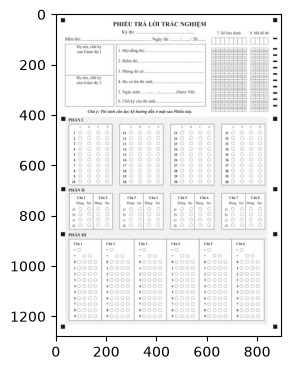

In [2]:
img_root = cv.imread('./data/sample1.jpg', cv.IMREAD_COLOR_BGR)
img = cv.cvtColor(img_root,cv.COLOR_BGR2GRAY)
plt.subplot(121),plt.imshow(img,cmap = 'gray')

(<Axes: >, <matplotlib.image.AxesImage at 0x22f05e51450>)

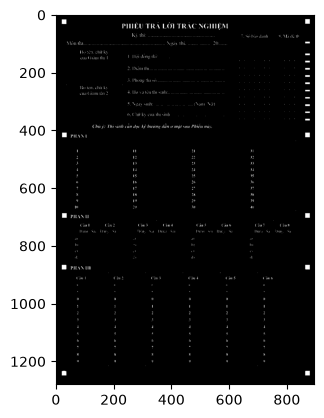

In [3]:
_, thresh = cv.threshold(img, 100, 255, cv.THRESH_BINARY_INV)
plt.subplot(111),plt.imshow(thresh,cmap = 'gray')


In [4]:
contours, _ = cv.findContours(thresh, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)

In [5]:
square_candidates = []
for c in contours:
    x,y,w,h = cv.boundingRect(c)
    area = cv.contourArea(c)

    if area < 100 or area > 5000:
        continue

    aspect_ratio = float(w) / h
    if not (0.85 <= aspect_ratio <= 1.15):
        continue

    extent = area / float(w * h)
    if extent < 0.80:
        continue

    M = cv.moments(c)
    if M['m00'] != 0:
        cx = M['m10'] /M['m00']
        cy = M['m01'] /M['m00']
        square_candidates.append({
            "contour": c,
            "bbox":(x,y,w,h),
            "center":(cx,cy),
            "area":area
        })
        

In [6]:
pts = np.array([c["center"] for c in square_candidates])

sum = pts[:,0] + pts[:,1]
tl = square_candidates[np.argmin(sum)] #top left
br = square_candidates[np.argmax(sum)] # btm right

different = pts[:,0] - pts[:,1]
tr = square_candidates[np.argmax(different)]
bl = square_candidates[np.argmin(different)]

src_corners = {
    "TL":tl,
    "TR":tr,
    "BR":br,
    "BL":bl
}

In [7]:
src_pts = np.array([b['center'] for b in src_corners.values()], dtype=np.float32)
dst_corners = np.array([
    [50, 50],             # Top-Left
    [1750, 50],           # Top-Right
    [1750, 2495],         # Bottom-Right
    [50, 2495]            # Bottom-Left
], dtype="float32")
M = cv.getPerspectiveTransform(src_pts, dst_corners)
warped_sheet = cv.warpPerspective(img, M, (1800, 2545))
status = cv.imwrite('output_grey.png', warped_sheet)

In [8]:
# draw rectangle to illustrate the result
for label,value in src_corners.items():
    bx,by,bw,bh = value['bbox']
    cv.rectangle(img_root, (bx, by), (bx + bw, by + bh), (255, 255, 0), 2)


Successfully generated 160 bubble coordinates!


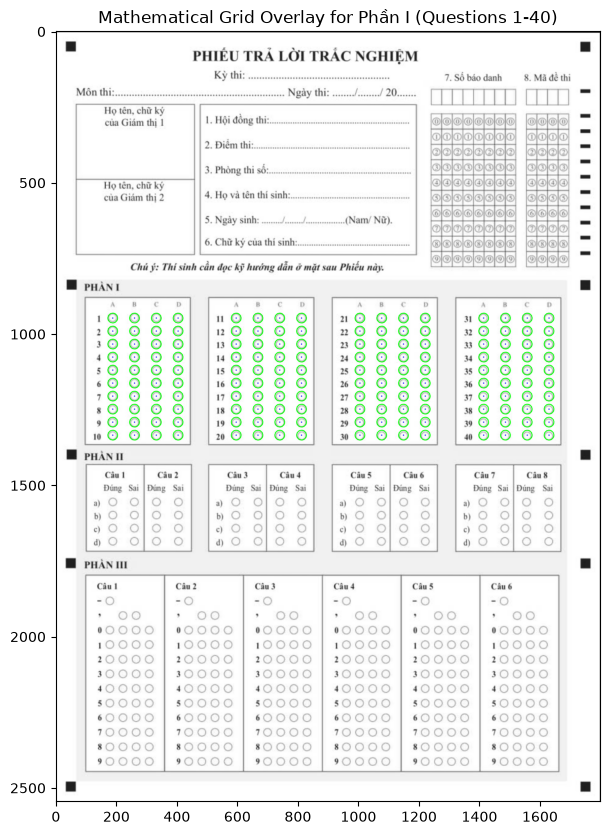

In [9]:
# 1. Grid Parameters
X_cols = [188, 596, 1005, 1414]  # X center of option 'A' for each column
Y_start = 947                    # Y center of the first row (Q1, Q11, Q21, Q31)
delta_x = 72                      # Horizontal distance between options A, B, C, D
delta_y = 43                      # Vertical distance between questions
bubble_radius = 16                # Radius of each bubble

options = ['A', 'B', 'C', 'D']
bubble_map = {}  # { (question_number, option_letter): (x, y, r) }

# 2. Mathematical Generation of all 160 bubbles
for col_idx in range(4):
    for row_idx in range(10):
        q_num = col_idx * 10 + row_idx + 1
        y = int(round(Y_start + row_idx * delta_y))
        
        for opt_idx in range(4):
            opt_letter = options[opt_idx]
            x = int(round(X_cols[col_idx] + opt_idx * delta_x))
            
            bubble_map[(q_num, opt_letter)] = (x, y, bubble_radius)

print(f"Successfully generated {len(bubble_map)} bubble coordinates!")

# 3. Visual Verification: Draw the calculated bubbles on warped_sheet
annotated = cv.cvtColor(warped_sheet, cv.COLOR_GRAY2BGR) if len(warped_sheet.shape) == 2 else warped_sheet.copy()

for (q, opt), (cx, cy, r) in bubble_map.items():
    # Green circle for bubble boundary
    cv.circle(annotated, (cx, cy), r, (0, 255, 0), 2)
    # Red dot for exact center
    cv.circle(annotated, (cx, cy), 2, (0, 0, 255), -1)

# Display Phần I region
plt.figure(figsize=(14, 10))
plt.imshow(annotated)
plt.title("Mathematical Grid Overlay for Phần I (Questions 1-40)")
plt.show()

## Test find contour after getPerspectiveTransform instead of define bubble manually 

warped_sheet is already transform

In [10]:
warped_sheet.shape

(2545, 1800)

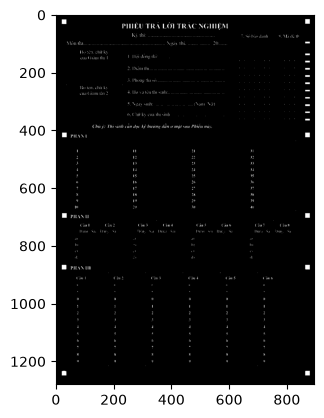

In [11]:
_, thresh_2 = cv.threshold(warped_sheet, 100, 255, cv.THRESH_BINARY_INV)
plt.imshow(thresh,"gray")

In [12]:
contours_2, _ = cv.findContours(thresh_2, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)

square_candidates_2 = []
for c in contours_2:
    x,y,w,h = cv.boundingRect(c)
    area = cv.contourArea(c)

    if area < 100 or area > 5000:
        continue

    aspect_ratio = float(w) / h
    if not (0.85 <= aspect_ratio <= 1.15):
        continue

    extent = area / float(w * h)
    if extent < 0.80:
        continue

    M = cv.moments(c)
    if M['m00'] != 0:
        cx = M['m10'] /M['m00']
        cy = M['m01'] /M['m00']
        square_candidates_2.append({
            "contour": c,
            "bbox":(x,y,w,h),
            "center":(cx,cy),
            "area":area
        })


In [13]:
part_1_squares = []
for c in square_candidates_2:
    if c['center'][1] >800 and c['center'][1] <1500:
        part_1_squares.append(c)


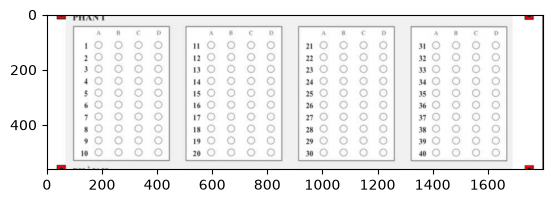

In [14]:
y_start = int(min(i['center'][1] for i in part_1_squares ))
y_end = int(max(i['center'][1] for i in part_1_squares ))
annotated = cv.cvtColor(warped_sheet,cv.COLOR_GRAY2BGR)
for i in part_1_squares:
    pts_1 = (int(i["center"][0]-10),int(i["center"][1]-10))
    pts_2 = (int(i["center"][0]+10),int(i["center"][1]+10))
    cv.rectangle(annotated,pts_1,pts_2,(255,0,0),5)
plt.imshow(annotated[y_start:y_end,:,:])

### export image

In [15]:
# cv.imwrite("perspective_transform.png",warped_sheet)

In [16]:
X_cols = [188, 596, 1005, 1414]  # X center of option 'A' for each column
Y_start = 947                    # Y center of the first row (Q1, Q11, Q21, Q31)
delta_x = 72                      # Horizontal distance between options A, B, C, D
delta_y = 43                      # Vertical distance between questions
bubble_radius = 16                # Radius of each bubble
options = ['A', 'B', 'C', 'D']
table = []
for column in range(4):
    cols = []
    for row in range(10):
        y = Y_start + row*delta_y
        bubble = []
        for choice in range(4):
            x = X_cols[column] + choice*delta_x
            bubble.append([x,y])
        cols.append(bubble)
    table.append(cols)

In [17]:
array  = np.array(table)

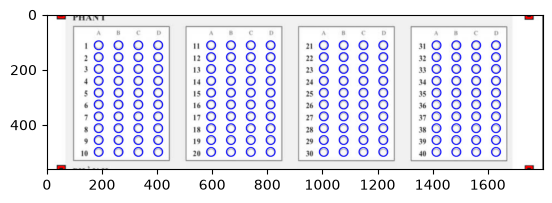

In [18]:
for column in range(array.shape[0]):
    for row in range(array.shape[1]):
        for choice in range(array.shape[2]):
            x, y = array[column, row, choice]

            cv.circle(
                annotated,
                (int(x), int(y)),
                bubble_radius,
                (0, 0, 255),
                2,
                cv.LINE_AA
            )
y_start = int(min(i['center'][1] for i in part_1_squares ))
y_end = int(max(i['center'][1] for i in part_1_squares ))
plt.imshow(annotated[y_start:y_end,:,:])

In [19]:
new_img = cv.imread("perspective_transform.png")

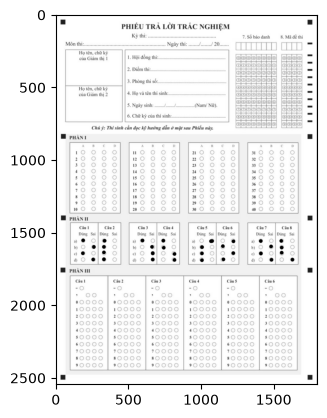

In [20]:
plt.imshow(new_img)

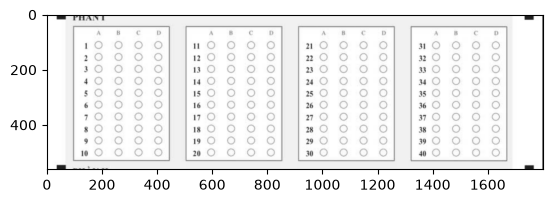

In [21]:
part_1 = new_img[y_start:y_end,:]
plt.imshow(part_1)

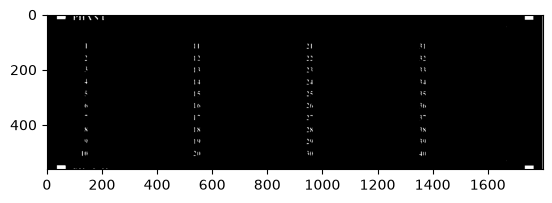

In [22]:
_,cvt_color = cv.threshold(new_img,100,255,cv.THRESH_BINARY_INV)
plt.imshow(cvt_color[y_start:y_end,:])

In [23]:
ques_ans = {}

for column in range(array.shape[0]):
    for row in range(array.shape[1]):
        ans = []
        for choice in range(array.shape[2]):
            x, y = array[column, row, choice]
            y_start = y - bubble_radius
            y_end = y + bubble_radius
            x_start = x - bubble_radius
            x_end = x + bubble_radius
            pixel_sum = cvt_color[y_start:y_end,x_start:x_end].sum()
            ans.append(pixel_sum)
        ques_ans[row+1 + column*10] = options[np.argmax(ans)]
ques_ans
            

{1: 'A',
 2: 'A',
 3: 'A',
 4: 'A',
 5: 'A',
 6: 'A',
 7: 'A',
 8: 'A',
 9: 'A',
 10: 'A',
 11: 'A',
 12: 'A',
 13: 'A',
 14: 'A',
 15: 'A',
 16: 'A',
 17: 'A',
 18: 'A',
 19: 'A',
 20: 'A',
 21: 'A',
 22: 'A',
 23: 'A',
 24: 'A',
 25: 'A',
 26: 'A',
 27: 'A',
 28: 'A',
 29: 'A',
 30: 'A',
 31: 'A',
 32: 'A',
 33: 'A',
 34: 'A',
 35: 'A',
 36: 'A',
 37: 'A',
 38: 'A',
 39: 'A',
 40: 'A'}

# Part 2


Q1ATrue: (188,1554) Q1AFalse: (259, 1554) Q2ATrue (259+72,1554)
x_gap = 72
y_gap = 42
Q1BTrue: (187,1596)

square_candidates_2

In [24]:
part_2_img = new_img.copy()

### 1. Grid Parameters


In [25]:
X_cols = [188, 596, 1005, 1414]  # X center of option 'A' for each column
Y_start = 1554                    # Y center of the first row (Q1, Q11, Q21, Q31)
delta_x = 72                      # Horizontal distance between options A, B, C, D
delta_y = 43                      # Vertical distance between questions
bubble_radius = 16                # Radius of each bubble
ques_gap = delta_x*2

### 2. Part 2 contour


In [26]:
table = []
for col in range(4):
    columns = []
    for ques in range(2):
        questions = []
        for sub in range(4):
            sub_ques = []
            y = Y_start + (sub)*delta_y
            for ans in range(2):
                x = X_cols[col] + (ans)*delta_x +ques*ques_gap
                sub_ques.append([x,y])
            questions.append(sub_ques)
        columns.append(questions)
    table.append(columns)

In [27]:
table = np.array(table)
table.shape

(4, 2, 4, 2, 2)

In [28]:
annotated = part_2_img.copy()
for col in range(4):
    for ques in range(2):
        for sub in range(4):
            for ans in range(2):
                x,y = table[col][ques][sub][ans]
                cv.circle(annotated,(int(x), int(y)),bubble_radius,(0, 0, 255),2,cv.LINE_AA)

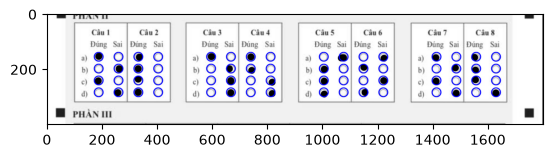

In [29]:
plt.imshow(annotated[1400:1800,:])

In [30]:
part_2_img_cvt = cv.threshold(new_img,100,255,cv.THRESH_BINARY_INV)

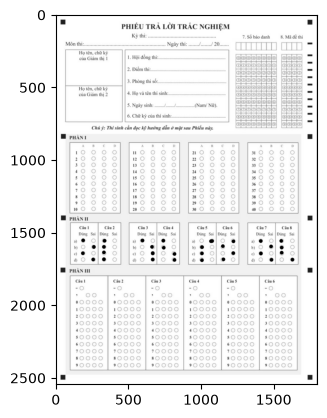

In [31]:
plt.imshow(part_2_img)

In [32]:
questions = {}
ans_options = ["A","B"]
for col in range(4):
    for ques in range(2):
        for sub in range(4):
            answers = []
            for ans in range(2):
                x,y = table[col,ques,sub,ans]
                y_start = y - bubble_radius 
                y_end = y + bubble_radius 
                x_start = x - bubble_radius 
                x_end = x + bubble_radius 
                pixel_sum = cvt_color[y_start:y_end,x_start:x_end].sum()
                answers.append(pixel_sum)
            questions[(ques+1 + col*2,options[sub])] = ans_options[np.argmax(answers)]
                
                

In [33]:
questions

{(1, 'A'): 'A',
 (1, 'B'): 'B',
 (1, 'C'): 'A',
 (1, 'D'): 'B',
 (2, 'A'): 'A',
 (2, 'B'): 'A',
 (2, 'C'): 'A',
 (2, 'D'): 'A',
 (3, 'A'): 'A',
 (3, 'B'): 'B',
 (3, 'C'): 'B',
 (3, 'D'): 'B',
 (4, 'A'): 'A',
 (4, 'B'): 'A',
 (4, 'C'): 'B',
 (4, 'D'): 'B',
 (5, 'A'): 'B',
 (5, 'B'): 'A',
 (5, 'C'): 'A',
 (5, 'D'): 'A',
 (6, 'A'): 'B',
 (6, 'B'): 'A',
 (6, 'C'): 'B',
 (6, 'D'): 'A',
 (7, 'A'): 'A',
 (7, 'B'): 'B',
 (7, 'C'): 'A',
 (7, 'D'): 'B',
 (8, 'A'): 'A',
 (8, 'B'): 'A',
 (8, 'C'): 'A',
 (8, 'D'): 'B'}